# Simulating the Stochastic-Quantum Correspondance

In [390]:
# Import libraries
from quspin.operators import hamiltonian, quantum_operator, quantum_LinearOperator, ishamiltonian
from quspin.basis import spin_basis_1d, tensor_basis
from quspin.tools.measurements import ent_entropy, diag_ensemble, obs_vs_time
from quspin.tools.misc import mean_level_spacing

from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import curve_fit, minimize
from scipy.stats import gaussian_kde
from tqdm import tqdm

from core import *

# Set default plot parameters
plt.rcParams["font.size"] = 18
plt.rcParams["font.family"] = "Arial"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

# Set random seed for reproducibility
rng = np.random.default_rng(42)

In [244]:
def construct_two_pixel_hamiltonian_analyzer(L, hx, hz, g):
    """
    Constructs the total HamiltonianAnalyzer for the system with and two pixels.

    Parameters:
        L (int): Number of spins in each pixel.
        hx (float): X latch-field strength on the pixel.
        hz (float): Z latch-field strength on the pixel.
        g (float): Qubit-pixel coupling strength.

    Returns:
        HamiltonianAnalyzer: Analyzer object for the two-pixel Hamiltonian.
    """
    # Basis for the qubit (site 0), pixel #1 (sites 1,...,L) and pixel #2 (sites L+1,...,2L)
    basis_list = [("spin", 1, True, {}), ("spin", L, True, {}), ("spin", L, True, {})]
    ha = HamiltonianAnalyzer(basis_list=basis_list)

    # Nearest-neighbor 1D Ising interaction (w. periodic BC) in each pixel
    ha.add_static_term(coeff=1., op_str="|zz|", sites=[[i, i + 1] for i in range(L - 1)] + [[L - 1, 0]])
    ha.add_static_term(coeff=1., op_str="||zz", sites=[[i, i + 1] for i in range(L - 1)] + [[L - 1, 0]])

    # "Latch" interaction between the qubit and pixel #1
    ha.add_static_term(coeff=hx / 2, op_str="|x|", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=hz / 2, op_str="|z|", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=hx / 2, op_str="z|x|", sites=[[0, i] for i in range(L)])
    ha.add_static_term(coeff=hz / 2, op_str="z|z|", sites=[[0, i] for i in range(L)])

    # "Latch" interaction between the qubit and pixel #2
    ha.add_static_term(coeff=hx / 2, op_str="||x", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=hz / 2, op_str="||z", sites=[[i] for i in range(L)])
    ha.add_static_term(coeff=-hx / 2, op_str="z||x", sites=[[0, i] for i in range(L)])
    ha.add_static_term(coeff=-hz / 2, op_str="z||z", sites=[[0, i] for i in range(L)])

    # Additional xz interaction between the qubit and each pixel
    ha.add_static_term(coeff=g, op_str="x|z|", sites=[[0, i] for i in range(L)])
    ha.add_static_term(coeff=g, op_str="x||z", sites=[[0, i] for i in range(L)])

    return ha

def compute_time_evolution_pauli(ha, times, psi0, eigvals=None, eigvecs=None, verbose=False, return_state=False):
    """
    Simulates the time evolution of the two-pixel system and computes the expectation values of Pauli operators.

    Parameters:
        ha (HamiltonianAnalyzer): Analyzer object containing the Hamiltonian and basis.
        times (array-like): Array of time points for evolution.
        psi0 (array-like): Initial state vector of the system.
        eigvals (array-like, optional): Eigenvalues of the Hamiltonian (if precomputed).
        eigvecs (array-like, optional): Eigenvectors of the Hamiltonian (if precomputed).
        verbose (bool, optional): If True, prints additional information during computation.
        return_state (bool, optional): If True, returns the state vector at each time step.

    Returns:
        dict: Dictionary with keys "X0-2", "Y0-2", "Z0-2" containing arrays of expectation values over time.
    """
    # Diagonalize the Hamiltonian if necessary
    if eigvals is None or eigvecs is None:
        eigvals, eigvecs = ha.diagonalize()

    L = ha.basis.N[1]  # Number of spins in each pixel

    obs_dict = {
        "X0": hamiltonian([["x||", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Y0": hamiltonian([["y||", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Z0": hamiltonian([["z||", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "X1": hamiltonian([["|x|", [[1.0 / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Y1": hamiltonian([["|y|", [[1.0j / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Z1": hamiltonian([["|z|", [[1.0 / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "X2": hamiltonian([["||x", [[1.0 / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Y2": hamiltonian([["||y", [[1.0j / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
        "Z2": hamiltonian([["||z", [[1.0 / L, i] for i in range(L)]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False)
    }

    obs_time = obs_vs_time(psi_t=(psi0, eigvals, eigvecs),
                           times=times, Obs_dict=obs_dict, verbose=verbose,
                           return_state=return_state)

    # Convert Y0-2 back to real values
    for Y_op in ["Y0", "Y1", "Y2"]:
        obs_time[Y_op] *= -1.0j
    for obs in obs_dict:
        if obs != "psi_time":
            obs_time[obs] = np.real(obs_time[obs])

    return obs_time

## Two-pixel dynamics (sanity check)

Hermiticity check passed!
Diagonalization took 0.0264 seconds.
obs_vs_time integrated to t=0.1000
obs_vs_time integrated to t=0.2000
obs_vs_time integrated to t=0.3000
obs_vs_time integrated to t=0.4000
obs_vs_time integrated to t=0.5000
obs_vs_time integrated to t=0.6000
obs_vs_time integrated to t=0.7000
obs_vs_time integrated to t=0.8000
obs_vs_time integrated to t=0.9000
obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=1.1000
obs_vs_time integrated to t=1.2000
obs_vs_time integrated to t=1.3000
obs_vs_time integrated to t=1.4000
obs_vs_time integrated to t=1.5000
obs_vs_time integrated to t=1.6000
obs_vs_time integrated to t=1.7000
obs_vs_time integrated to t=1.8000
obs_vs_time integrated to t=1.9000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=2.1000
obs_vs_time integrated to t=2.2000
obs_vs_time integrated to t=2.3000
obs_vs_time integrated to t=2.4000
obs_vs_time integrated to t=2.5000
obs_vs_time integrated to t=2.6000
obs_vs_time integrated to t

C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:63: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "X0": hamiltonian([["x||", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:64: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Y0": hamiltonian([["y||", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:65: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Z0": hamiltonian([["z||", [[1.0, 0]]]], [],

obs_vs_time integrated to t=6.8000
obs_vs_time integrated to t=6.9000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=7.1000
obs_vs_time integrated to t=7.2000
obs_vs_time integrated to t=7.3000
obs_vs_time integrated to t=7.4000
obs_vs_time integrated to t=7.5000
obs_vs_time integrated to t=7.6000
obs_vs_time integrated to t=7.7000
obs_vs_time integrated to t=7.8000
obs_vs_time integrated to t=7.9000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=8.1000
obs_vs_time integrated to t=8.2000
obs_vs_time integrated to t=8.3000
obs_vs_time integrated to t=8.4000
obs_vs_time integrated to t=8.5000
obs_vs_time integrated to t=8.6000
obs_vs_time integrated to t=8.7000
obs_vs_time integrated to t=8.8000
obs_vs_time integrated to t=8.9000
obs_vs_time integrated to t=9.0000
obs_vs_time integrated to t=9.1000
obs_vs_time integrated to t=9.2000
obs_vs_time integrated to t=9.3000
obs_vs_time integrated to t=9.4000
obs_vs_time integrated to t=9.5000
obs_vs_time integrat

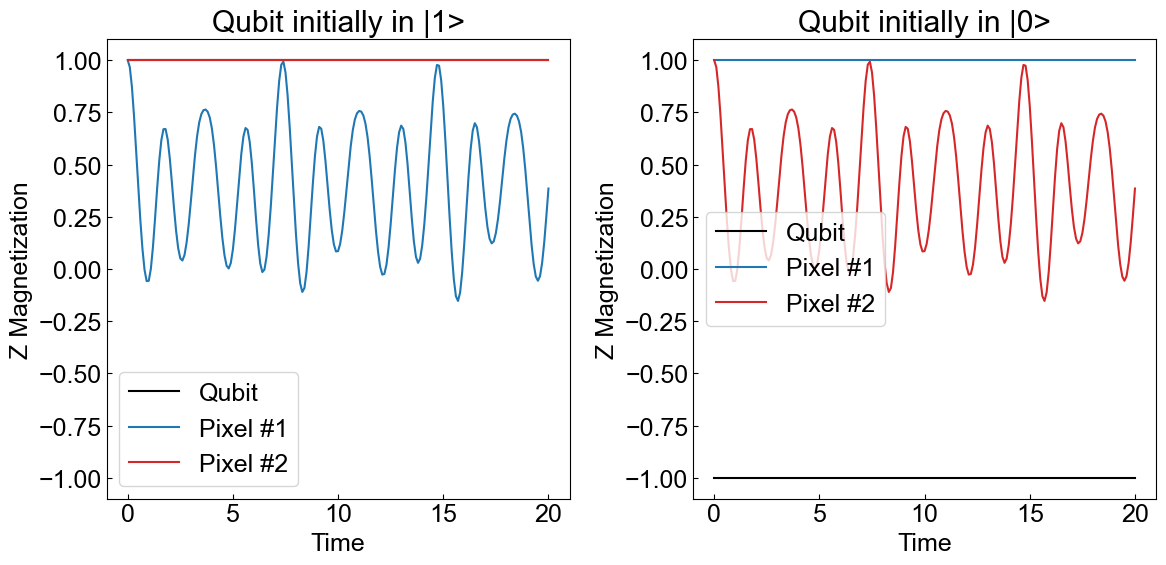

In [245]:
# Simulating for not extra qubit-pixel coupling (i.e., g=0)
L = 3
hx = 1.3
hz = -0.3
g = 0.

ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, g)
N = ha.basis.Ns
eigvals, eigvecs = ha.diagonalize(timeit=True)

dt = 0.1
times = np.arange(0, 20 + dt, dt)

# Qubit initially in |1>
psi0 = np.zeros(N, dtype=np.complex128)
psi0[0] = 1.
obs_time_1 = compute_time_evolution_pauli(ha, times, psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=True)

# Qubit initially in |0>
psi0 = np.zeros(N, dtype=np.complex128)
psi0[N // 2] = 1.
obs_time_0 = compute_time_evolution_pauli(ha, times, psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=True)

# Visualize qubit and pixel z magnetizations
fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

axs[0].plot(times, obs_time_1["Z0"], label="Qubit", color="k")
axs[0].plot(times, obs_time_1["Z1"], label="Pixel #1", color="C0")
axs[0].plot(times, obs_time_1["Z2"], label="Pixel #2", color="C3")
axs[0].set_ylim(-1.1, 1.1)
axs[0].set_title("Qubit initially in |1>")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Z Magnetization")
axs[0].legend()

axs[1].plot(times, obs_time_0["Z0"], label="Qubit", color="k")
axs[1].plot(times, obs_time_0["Z1"], label="Pixel #1", color="C0")
axs[1].plot(times, obs_time_0["Z2"], label="Pixel #2", color="C3")
axs[1].set_ylim(-1.1, 1.1)
axs[1].set_title("Qubit initially in |0>")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Z Magnetization")
axs[1].legend()

plt.tight_layout()
plt.show()

Hermiticity check passed!
Diagonalization took 0.2904 seconds.
obs_vs_time integrated to t=0.1000
obs_vs_time integrated to t=0.2000
obs_vs_time integrated to t=0.3000
obs_vs_time integrated to t=0.4000
obs_vs_time integrated to t=0.5000
obs_vs_time integrated to t=0.6000
obs_vs_time integrated to t=0.7000
obs_vs_time integrated to t=0.8000
obs_vs_time integrated to t=0.9000
obs_vs_time integrated to t=1.0000
obs_vs_time integrated to t=1.1000
obs_vs_time integrated to t=1.2000
obs_vs_time integrated to t=1.3000
obs_vs_time integrated to t=1.4000
obs_vs_time integrated to t=1.5000
obs_vs_time integrated to t=1.6000
obs_vs_time integrated to t=1.7000
obs_vs_time integrated to t=1.8000
obs_vs_time integrated to t=1.9000
obs_vs_time integrated to t=2.0000
obs_vs_time integrated to t=2.1000
obs_vs_time integrated to t=2.2000
obs_vs_time integrated to t=2.3000
obs_vs_time integrated to t=2.4000
obs_vs_time integrated to t=2.5000
obs_vs_time integrated to t=2.6000
obs_vs_time integrated to t

C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:63: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "X0": hamiltonian([["x||", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:64: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Y0": hamiltonian([["y||", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:65: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Z0": hamiltonian([["z||", [[1.0, 0]]]], [],

obs_vs_time integrated to t=5.4000
obs_vs_time integrated to t=5.5000
obs_vs_time integrated to t=5.6000
obs_vs_time integrated to t=5.7000
obs_vs_time integrated to t=5.8000
obs_vs_time integrated to t=5.9000
obs_vs_time integrated to t=6.0000
obs_vs_time integrated to t=6.1000
obs_vs_time integrated to t=6.2000
obs_vs_time integrated to t=6.3000
obs_vs_time integrated to t=6.4000
obs_vs_time integrated to t=6.5000
obs_vs_time integrated to t=6.6000
obs_vs_time integrated to t=6.7000
obs_vs_time integrated to t=6.8000
obs_vs_time integrated to t=6.9000
obs_vs_time integrated to t=7.0000
obs_vs_time integrated to t=7.1000
obs_vs_time integrated to t=7.2000
obs_vs_time integrated to t=7.3000
obs_vs_time integrated to t=7.4000
obs_vs_time integrated to t=7.5000
obs_vs_time integrated to t=7.6000
obs_vs_time integrated to t=7.7000
obs_vs_time integrated to t=7.8000
obs_vs_time integrated to t=7.9000
obs_vs_time integrated to t=8.0000
obs_vs_time integrated to t=8.1000
obs_vs_time integrat

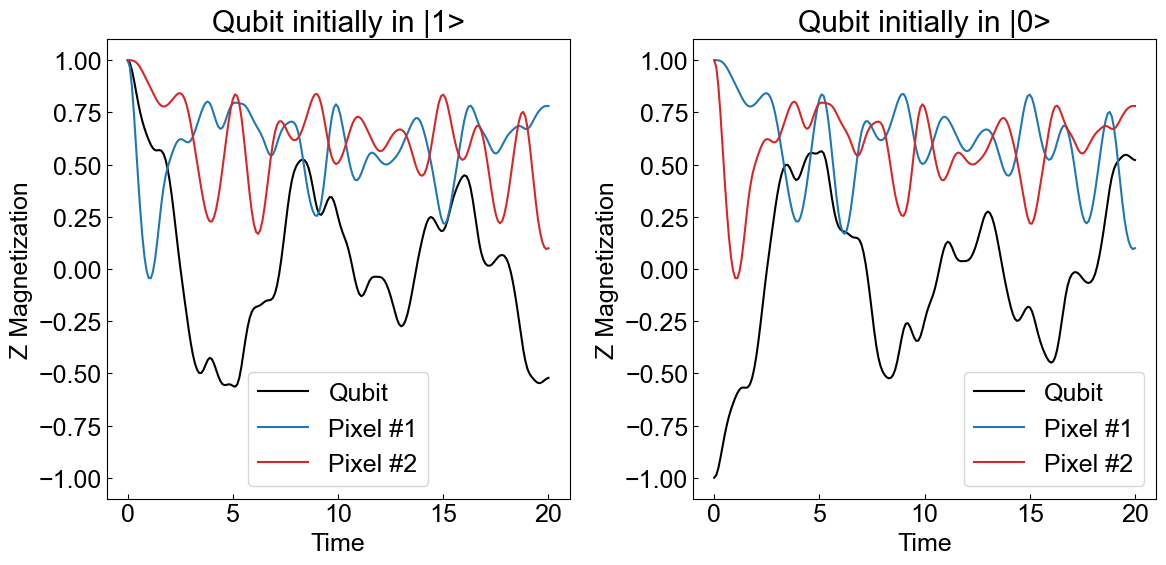

In [275]:
# Simulating with some extra qubit-pixel coupling (i.e., nonzero g)
L = 4
hx = 1.3
hz = -0.3
g = 0.1

ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, g)
N = ha.basis.Ns
eigvals, eigvecs = ha.diagonalize(timeit=True)

dt = 0.1
times = np.arange(0, 20 + dt, dt)

# Qubit initially in |1>
psi0 = np.zeros(N, dtype=np.complex128)
psi0[0] = 1.
obs_time_1 = compute_time_evolution_pauli(ha, times, psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=True)

# Qubit initially in |0>
psi0 = np.zeros(N, dtype=np.complex128)
psi0[N // 2] = 1.
obs_time_0 = compute_time_evolution_pauli(ha, times, psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=True)

# Visualize qubit and pixel z magnetizations
fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

axs[0].plot(times, obs_time_1["Z0"], label="Qubit", color="k")
axs[0].plot(times, obs_time_1["Z1"], label="Pixel #1", color="C0")
axs[0].plot(times, obs_time_1["Z2"], label="Pixel #2", color="C3")
axs[0].set_ylim(-1.1, 1.1)
axs[0].set_title("Qubit initially in |1>")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Z Magnetization")
axs[0].legend()

axs[1].plot(times, obs_time_0["Z0"], label="Qubit", color="k")
axs[1].plot(times, obs_time_0["Z1"], label="Pixel #1", color="C0")
axs[1].plot(times, obs_time_0["Z2"], label="Pixel #2", color="C3")
axs[1].set_ylim(-1.1, 1.1)
axs[1].set_title("Qubit initially in |0>")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Z Magnetization")
axs[1].legend()

plt.tight_layout()
plt.show()

## Divisibility of the SQC Transition matrix

In [496]:
def compute_sqc_transition_matrix(ha, times, verbose=False):
    """
    Computes the SQC transition matrices of the system over specified time points.

    Parameters:
        ha (HamiltonianAnalyzer): Analyzer object containing the two-pixel Hamiltonian.
        times (array-like): Monotonic array of time points.
        verbose (bool, optional): If True, prints additional information during computation.

    Returns:
        tuple:
            obs_time_0 (dict): Time evolution and observables for initial |0> state.
            obs_time_1 (dict): Time evolution and observables for initial |1> state.
            G00 (np.ndarray): Shape (Nt,). Gamma_00(0->t) = P(qubit=|0> at time t | qubit=|0> at t=0).
            G11 (np.ndarray): Shape (Nt,). Gamma_11(0->t) = P(qubit=|1> at time t | qubit=|1> at t=0).
            G00_mat (np.ndarray): Shape (Nt, Nt). Row idx t': Gamma_00(t'->t) for t >= t'.
            G11_mat (np.ndarray): Shape (Nt, Nt). Row idx t': Gamma_11(t'->t) for t >= t'.
            D00_mat (np.ndarray): Shape (Nt, Nt). Deviation from divisibility for |0> branch:
                                  G00(0->t) - G00(t'->t)G00(0->t') - (1-G00(t'->t))(1-G11(0->t')).
            D11_mat (np.ndarray): Shape (Nt, Nt). Deviation from divisibility for |1> branch:
                                  G11(0->t) - G11(t'->t)G11(0->t') - (1-G11(t'->t))(1-G00(0->t')).
    """
    # Diagonalize the Hamiltonian
    eigvals, eigvecs = ha.diagonalize()
    N = ha.basis.Ns

    # Compute transition matrix at each time point
    # Gamma00(0 -> t)
    psi0 = np.zeros(N, dtype=np.complex128)
    psi0[0] = 1.
    obs_time_0 = compute_time_evolution_pauli(ha, times, psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=verbose, return_state=True)
    G00 = 0.5 * (1 + obs_time_0["Z0"])

    # Gamma11(0 -> t)
    psi0 = np.zeros(N, dtype=np.complex128)
    psi0[N // 2] = 1.
    obs_time_1 = compute_time_evolution_pauli(ha, times, psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=verbose, return_state=True)
    G11 = 0.5 * (1 - obs_time_1["Z0"])

    # Compute deviation from divisibility
    Nt = len(times)
    G00_mat, G11_mat = np.zeros((Nt, Nt)), np.zeros((Nt, Nt))
    G00_mat[0], G11_mat[0] = G00, G11

    for idx in tqdm(range(1, Nt), desc="Computing deviation from divisibility"):
        psi_tp0 = obs_time_0["psi_t"][:, idx]
        psi_tp1 = obs_time_1["psi_t"][:, idx]

        # Gamma00(t' -> t)
        psi0 = np.zeros(N, dtype=np.complex128)
        psi0[:N // 2] = psi_tp0[:N // 2]
        psi0 /= np.linalg.norm(psi0)
        obs_time_0_curr = compute_time_evolution_pauli(ha, times[idx:] - times[idx], psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=verbose, return_state=False)
        G00_mat[idx, idx:] = 0.5 * (1 + obs_time_0_curr["Z0"])

        # Gamma11(t' -> t)
        psi0 = np.zeros(N, dtype=np.complex128)
        psi0[N // 2:] = psi_tp1[N // 2:]
        psi0 /= np.linalg.norm(psi0)
        obs_time_1_curr = compute_time_evolution_pauli(ha, times[idx:] - times[idx], psi0, eigvals=eigvals, eigvecs=eigvecs, verbose=verbose, return_state=False)
        G11_mat[idx, idx:] = 0.5 * (1 - obs_time_1_curr["Z0"])

    D00_mat = G00[np.newaxis, :] - G00_mat * G00[:, np.newaxis] - (1 - G11_mat) * (1 - G00[:, np.newaxis])
    D11_mat = G11[np.newaxis, :] - G11_mat * G11[:, np.newaxis] - (1 - G00_mat) * (1 - G11[:, np.newaxis])

    # D00_mat, D11_mat = np.zeros((Nt, Nt)), np.zeros((Nt, Nt))
    # for i in tqdm(range(Nt)):
    #     for j in range(i, Nt):
    #         opt_res = minimize(lambda x: np.abs(G00[j] - x[0] * G00[i] - (1 - x[1]) * (1 - G00[i])) + np.abs(G11[j] - x[0] * G11[i] - (1 - x[1]) * (1 - G11[i])),
    #                               x0=(1, 1), method="Nelder-Mead", bounds=((0, 1), (0, 1)))

    #         D00_mat[i, j] = G00[j] - opt_res.x[0] * G00[i] - (1 - opt_res.x[1]) * (1 - G00[i])
    #         D11_mat[i, j] = G11[j] - opt_res.x[0] * G11[i] - (1 - opt_res.x[1]) * (1 - G11[i])

    tri_ones_upper = np.triu(np.ones_like(G00_mat))
    D00_mat *= tri_ones_upper
    D11_mat *= tri_ones_upper

    return obs_time_0, obs_time_1, G00, G11, G00_mat, G11_mat, D00_mat, D11_mat

In [547]:
# Compute SQC transition matrices without extra qubit-pixel coupling (i.e., g=0)
L = 5  # Number of spins in each pixel
hx = 1.3  # X field strength
hz = -0.3  # Z field strength
g = 0.1  # Pixel "backaction" on qubit
ha = construct_two_pixel_hamiltonian_analyzer(L, hx, hz, g)

dt = 0.1
times = np.arange(0, 50 + dt, dt)
obs_time_0, obs_time_1, G00, G11, G00_mat, G11_mat, D00_mat, D11_mat = compute_sqc_transition_matrix(ha, times, verbose=False)

Hermiticity check passed!


C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:63: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "X0": hamiltonian([["x||", [[1.0, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:64: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Y0": hamiltonian([["y||", [[1.0j, 0]]]], [], basis=ha.basis, dtype=np.complex128, check_symm=False, check_herm=False),
C:\Users\matan\AppData\Local\Temp\ipykernel_27304\1189120649.py:65: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  "Z0": hamiltonian([["z||", [[1.0, 0]]]], [],

0.3582469887767926 -0.3664114115624365


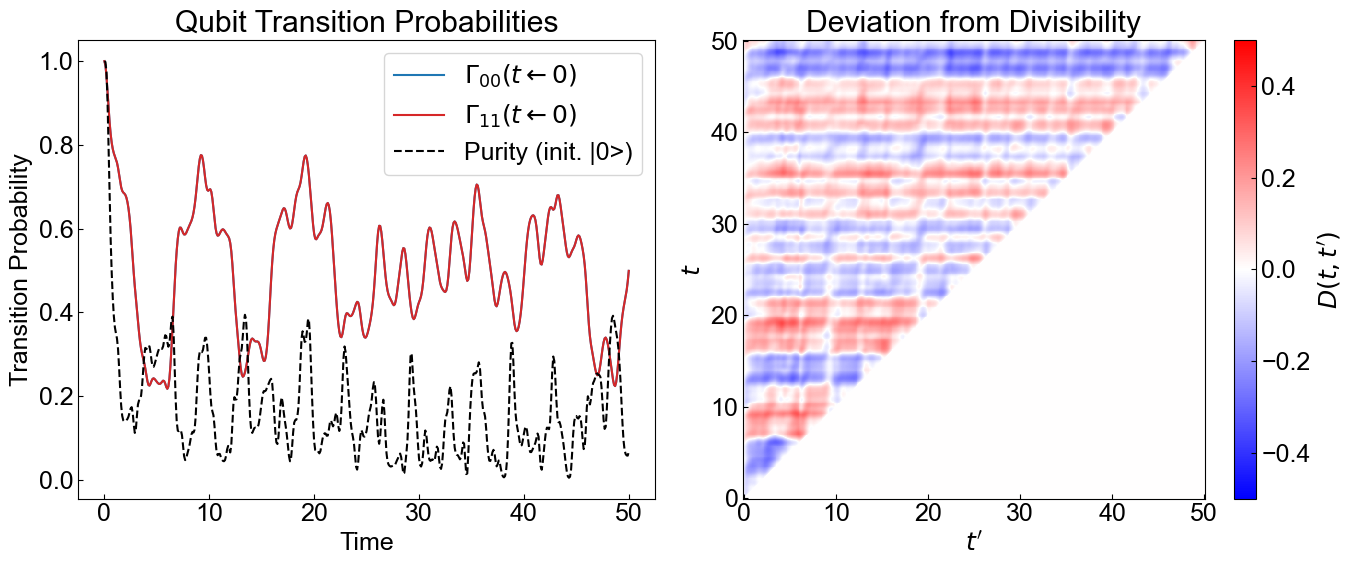

In [548]:
# Plot transition matrix components
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
axs[0].plot(times, G00, label=r"$\Gamma_{00}(t \leftarrow 0)$", color="C0")
axs[0].plot(times, G11, label=r"$\Gamma_{11}(t \leftarrow 0)$", color="C3")
axs[0].plot(times, obs_time_0["X0"] ** 2 + obs_time_0["Y0"] ** 2 + obs_time_0["Z0"] ** 2, label=r"Purity (init. |0>)", color="k", linestyle="--")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Transition Probability")
axs[0].set_title("Qubit Transition Probabilities")
axs[0].legend()

# Plot deviation from divisibility
print(D00_mat.max(), D00_mat.min())
im = axs[1].pcolormesh(times, times, D00_mat.T, shading="auto", cmap="bwr", vmin=-0.5, vmax=0.5)
axs[1].set_xlabel(r"$t'$")
axs[1].set_ylabel(r"$t$")
axs[1].set_title("Deviation from Divisibility")
fig.colorbar(im, ax=axs[1], label="$D(t,t')$")

plt.tight_layout()
plt.show()

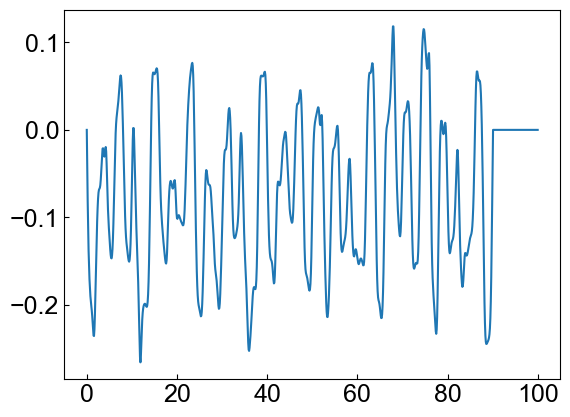

In [546]:
plt.plot(times, D00_mat[:, -100])